# Logistic Regression
### Definition
Logistic regression is a classical machine learning classification algorithm consisting of a single neuron. It is similarily structured to the Perceptron, but it differs in utilizing a well fit logistic function to the data rather than a step function. Because of this, it outputs a confidence value, rather than a binary output. The logistic function is provided as such:
$$
f(z) = \frac{1}{1+e^{-x}}
$$

However, this is the only way in which it differs from the perceptron model.

Given a set of training data $X$ and training results $y$, with weights $W$ and bias $b$, a single neuron Logistic Regression model can be trained with the following algorithm:

1. Compute $z=WX+b$
2. Compute $a = f(z)$
3. Let $\hat{y} = a$
4. Adjust weights: $W = W - \eta (y - \hat{y}) X
5. Adjust biases: $b = b - \eta (y - \hat{y})
6. Continue until the maximum number of epochs is reached.

### Advantages
- Works quickly for binary linear classification problems
- Confidence value provides more data than the Perceptron's binary output
- Because of this, it is more widely used in Multilayer models
- Often fits binary linear classification models better than perceptron
### Disadvantages
- Still limited usefulness outside of specific binary linear classification problems
- Doesn't have the same hard boundary that the Perceptron has, which could be useful

# Imports

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

# Data
We will load in the Titanic data that we created in the preprocessing step:

In [75]:
data_dir = "/home/patrick/Projects/DataScienceAndMachineLearning/Data/Titanic-Dataset"
train_X = np.load(f"{data_dir}/train_X.npy")
train_y = np.load(f"{data_dir}/train_y.npy")
test_X = np.load(f"{data_dir}/test_X.npy")
test_y = np.load(f"{data_dir}/test_y.npy")
PCA_train_X = np.load(f"{data_dir}/PCA_train_X.npy")
PCA_train_y = np.load(f"{data_dir}/PCA_train_y.npy")
PCA_test_X = np.load(f"{data_dir}/PCA_test_X.npy")
PCA_test_y = np.load(f"{data_dir}/PCA_test_y.npy")
train_X

array([[ 3.,  0., 22., ...,  1.,  0.,  0.],
       [ 1.,  1., 38., ...,  0.,  1.,  0.],
       [ 3.,  1., 26., ...,  0.,  1.,  0.],
       ...,
       [ 3.,  0., 27., ...,  1.,  0.,  0.],
       [ 1.,  0., 42., ...,  1.,  0.,  0.],
       [ 3.,  0., 20., ...,  1.,  0.,  0.]], shape=(622, 14))

Now, we decide what data to use logistic regression on. We will use the second principal component, as the means seem to differ. We will check this by calculating cohen's d, which gives us the difference between two means. The higher it is, the larger the difference between the means, and thus the better than the logistic regression will be able to model the data.

In [97]:
train_col = PCA_train_X[:, 1]
survived_vals = train_col[PCA_train_y == 1]
dead_vals = train_col[PCA_train_y == 0]
mean_diff = survived_vals.mean() - dead_vals.mean()
std = np.sqrt((dead_vals.std()**2 + survived_vals.std()**2)/2)
cohens_d = mean_diff / std
print(cohens_d)

-0.6804313901899188


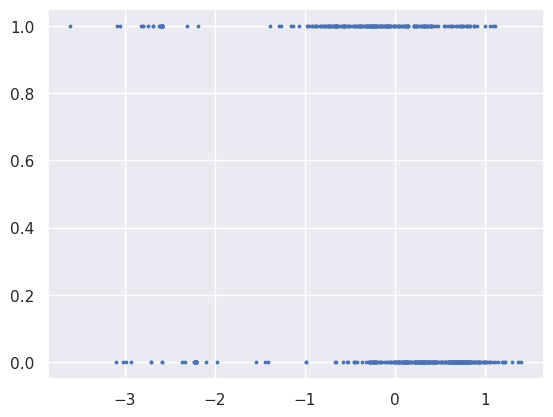

In [98]:
# PCA_train_X[:, 1] = -(np.exp(PCA_train_X[:, 1]))**1/3
plt.scatter(PCA_train_X[:, 1], PCA_train_y, s=3)

Now, we implement the Logistic Regression Neuron:

In [93]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

In [ ]:
class LogisticNeuron():
    def __init__(self, _activation_function):
        self.activation_function = _activation_function

    def train(self, X, y, eta = 0.01, epochs = 100):
        self.weight = np.random.rand()
        self.bias = np.random.rand()
        self.dim = X.shape[0]
        errors = np.empty(epochs)
        for epoch in range(epochs):
            y_hats = np.empty(self.dim)
            for i in range(self.dim):
                y_hats[i] = self.feed_forward(X[i])
            for i in range(self.dim):
                self.weight += -eta * (y_hats[i] - y[i]) * X[i]
                self.bias += -eta * (y_hats[i] - y[i])
            errors[epoch] = self.cost(y, y_hats)
        return errors
    
    def cost(self, y, y_hat):
        cost = 0.0
        for i in range(self.dim):
            cost += -y[i] * np.log(y_hat[i]) - (1.0 - y[i]) * np.log(1.0 - y_hat[i])
        return cost

    def feed_forward(self, x):
        return self.activation_function(self.weight * x + self.bias)
        

Now, we train the model:

In [99]:
neuron = LogisticNeuron(sigmoid)
neuron.train(PCA_train_X[:, 1], PCA_train_y, eta = 0.01, epochs = 10000)

array([491.01028123, 400.83028861, 385.76229943, ..., 384.97084256,
       384.97084256, 384.97084256], shape=(10000,))

Output training percentages:

In [100]:
train_values = [round(neuron.feed_forward(x)) for x in PCA_train_X[:, 1]]
exact_values = [int(y) for y in PCA_train_y]

train_error = sum(not exact_values[i]^train_values[i] for i in range(np.shape(PCA_train_X)[0]))
percent_train_correctly_classified = train_error / np.shape(PCA_train_X)[0]
number_train_correctly_classified = train_error

print(f"Percent of training predictions correct = {percent_train_correctly_classified*100.0:2.2f}%")
print(str(number_train_correctly_classified), "correctly classified out of", str(len(PCA_test_X)))

Percent of training predictions correct = 66.24%
412 correctly classified out of 267


Plot estimated sigmoid function for training data:

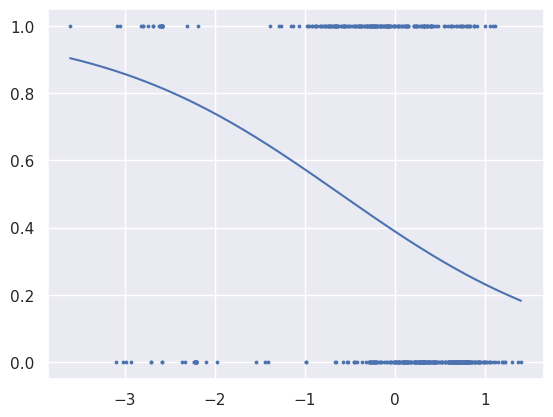

In [101]:
plt.scatter(PCA_train_X[:, 1], PCA_train_y, s=3)

t = np.linspace(min(PCA_train_X[:, 1]), max(PCA_train_X[:, 1]), 1000)
t_y = [neuron.feed_forward(x) for x in t]
plt.plot(t, t_y)
plt.show()

Output testing percentages:

In [102]:
test_values = [round(neuron.feed_forward(x)) for x in PCA_test_X[:, 1]]
exact_values = [int(y) for y in PCA_test_y]

test_error = sum(not exact_values[i]^test_values[i] for i in range(np.shape(PCA_test_X)[0]))
percent_test_correctly_classified = test_error / np.shape(PCA_test_X)[0]
number_test_correctly_classified = test_error

print(f"Percent of testing predictions correct = {percent_test_correctly_classified*100.0:2.2f}%")
print(str(number_test_correctly_classified), "correctly classified out of", str(len(PCA_test_X)))

Percent of testing predictions correct = 67.42%
180 correctly classified out of 267


Plot estimated sigmoid function with testing data:

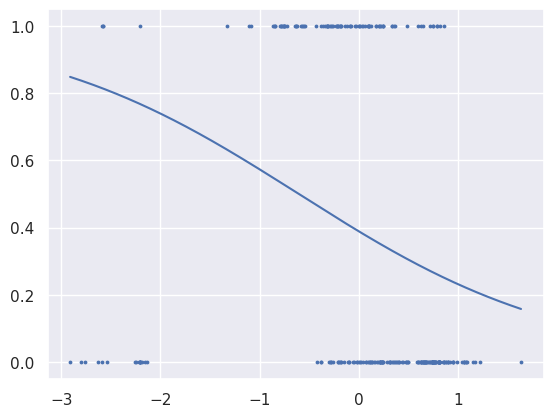

In [103]:
plt.scatter(PCA_test_X[:, 1], PCA_test_y, s=3)

t = np.linspace(min(PCA_test_X[:, 1]), max(PCA_test_X[:, 1]), 1000)
t_y = [neuron.feed_forward(x) for x in t]
plt.plot(t, t_y)
plt.show()